# 04 · Reproducing Canciani 2022 — online calibration (38-state EKF)

On a real F-16 the aircraft's magnetic field is enormous and *changes during the flight*, so a calibration done once goes stale. Canciani's idea: fold the Tolles-Lawson calibration **into** the navigation filter and keep re-estimating it live — **"tightly-coupled"** (online) — instead of freezing it — **"loosely-coupled"** (the classic approach).

The filter carries **38 states**: a 15-state INS error model, 19 Tolles-Lawson coefficients, a world-frame bias, and the 3 fluxgate readings. We run it both ways and compare.

The F-16 data is not public, so we use public Cessna data. The absolute errors are smaller than the paper's, but the qualitative result — tightly-coupled beats loosely-coupled — reproduces.

In [1]:
import os, sys
while not os.path.isdir('magnavlab') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, os.getcwd())
print('repo:', os.getcwd())

repo: /home/wpalka/magnav


## 1. Flight, map, segment and kinematics
`build_kinematics` derives the velocities, specific forces, heading and body-to-navigation rotation that the filter's INS model needs.

In [2]:
%matplotlib inline
import numpy as np
from magnavlab.io import load_flight, load_map, segment_indices
from magnavlab import data, viz
from magnavlab.ins import build_kinematics, simulate_ins_pinson
from magnavlab.calibration import MapBasedModifiedTL
from magnavlab.filters import Canciani38EKF
from magnavlab.interfaces import NavProblem, NavResult
from magnavlab.geo import horizontal_error
from magnavlab.geomag import core_field
from magnavlab.metrics import summary

nav = load_flight('data/Flt1003_train.h5')
mag_map = load_map('data/maps/Eastern_395.h5')
idx = segment_indices(nav, 50713.0, 54497.0)[::5]; dt = nav.dt * 5; n = idx.size
lat = np.radians(nav.get('lat')[idx]); lon = np.radians(nav.get('lon')[idx])
alt = nav.get('alt')[idx]; tt = nav.get('tt')[idx]
kinematics = build_kinematics(lat, lon, alt, dt,
                              np.radians(nav.get('roll')[idx]), np.radians(nav.get('pitch')[idx]))

## 2. Sensor signals
The raw cabin scalar (`mag_4_uc`, still full of the aircraft field; the daily/diurnal variation is removed), the fluxgate vector, the **core field from the IGRF model** (the map has the core removed, so the measurement equation adds it back), and the direction-cosine rates that drive the eddy-current terms.

In [3]:
flux = nav.flux(idx)
scalar = nav.get('mag_4_uc')[idx].astype(float) - nav.get('diurnal')[idx]
core = core_field(lat, lon, alt)                 # IGRF main field along the track [nT]
cos_x, cos_y, cos_z = flux.x/scalar, flux.y/scalar, flux.z/scalar
cos_dot = (np.gradient(cos_x, dt), np.gradient(cos_y, dt), np.gradient(cos_z, dt))

## 3. Simulate a navigation-grade drifting INS
Integrating the Pinson error model with small IMU biases gives a realistic drift of about a kilometre over the hour — the error the magnetic filter has to undo.

In [4]:
ins, _ = simulate_ins_pinson(lat, lon, alt, kinematics, dt)
ins_drift = horizontal_error(ins['lat'], ins['lon'], lat, lon, lat)
print(f'INS drift: end={ins_drift[-1]:.0f} m, max={ins_drift.max():.0f} m')

INS drift: end=1083 m, max=1083 m


## 4. Batch calibration to initialise the filter
A one-shot map-based Tolles-Lawson fit on the first half of the flight provides the filter's starting coefficients and their uncertainty (eq. 23 of the paper).

In [5]:
half = n // 2
earth_field = mag_map.value(lat[:half], lon[:half]) + core[:half]
tl_batch = MapBasedModifiedTL().fit(nav.flux(idx[:half]), scalar[:half], dt, target=earth_field)
print(f'batch T-L residual = {tl_batch.resid_std:.1f} nT')

batch T-L residual = 36.4 nT


## 5. Run loosely- vs tightly-coupled
Same problem, two modes. `loosely` keeps the batch coefficients **frozen**; `tightly` keeps **refining** them online as the flight proceeds.

In [6]:
problem = NavProblem(dt=dt, map=mag_map, lat=ins['lat'], lon=ins['lon'], alt=ins['alt'],
                     vN=ins['vN'], vE=ins['vE'], vD=ins['vD'], meas=scalar, core=core,
                     flux=flux, cos_dot=cos_dot, fn=kinematics['fn'], fe=kinematics['fe'],
                     fd=kinematics['fd'], Cnb=kinematics['Cnb'], tl0=tl_batch.coef, P_tl0=tl_batch.P_cov)
loose = Canciani38EKF(mode='loosely').run(problem)
tight = Canciani38EKF(mode='tightly').run(problem)
ins_result = NavResult(lat=ins['lat'], lon=ins['lon'])
for name, result in [('INS', ins_result), ('loosely', loose), ('tightly', tight)]:
    print(f"{name:9s} DRMS={summary(result, lat, lon)['drms']:8.1f} m")
ml = summary(loose, lat, lon)['drms']; mt = summary(tight, lat, lon)['drms']
print(f'improvement tightly vs loosely: {100*(1-mt/ml):.0f}%')

INS       DRMS=   493.5 m
loosely   DRMS=   100.2 m
tightly   DRMS=    56.4 m
improvement tightly vs loosely: 44%


## 6. Estimated position vs truth, on the map
**Black = truth**; the loosely- and tightly-coupled estimates are overlaid on the anomaly field, zoomed in tight. The tightly-coupled track stays visibly closer to the black line.

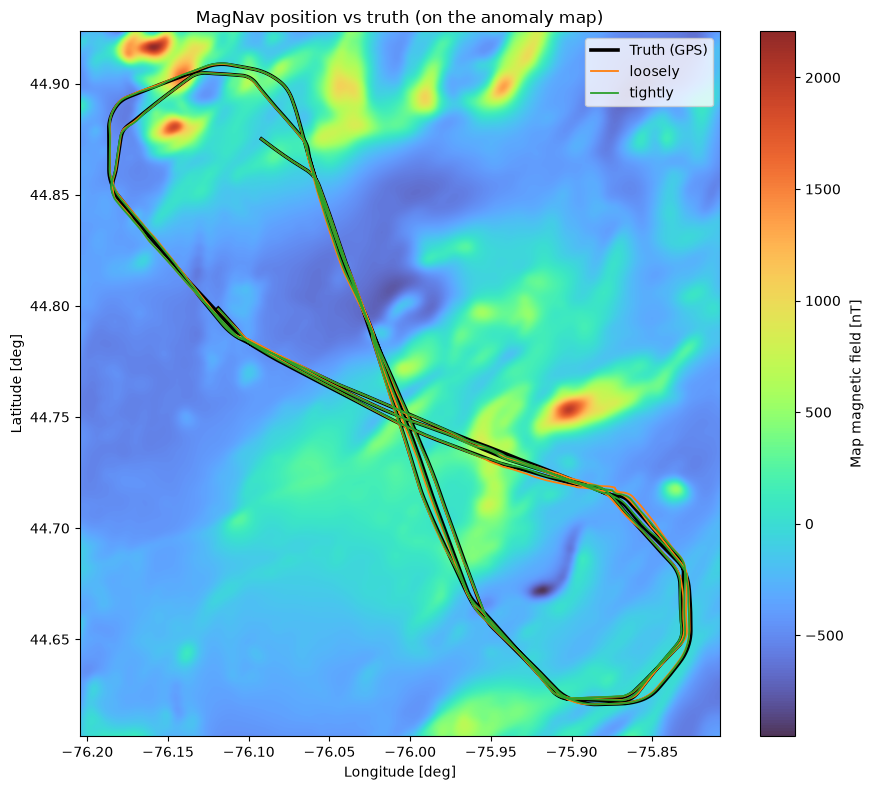

In [7]:
viz.plot_tracks_vs_truth(mag_map, lat, lon,
    {'loosely': (loose, 'tab:orange'), 'tightly': (tight, 'tab:green')});

## 7. North/East error, and the live calibration
**Top two panels** — north and east position error in metres versus time (the format of the paper's Fig. 12–15); tightly-coupled is consistently tighter. **Bottom panel** — the filter's estimated permanent-field Tolles-Lawson coefficients drifting over time: this is the online calibration adjusting to the changing aircraft field, and it is what buys the extra accuracy.

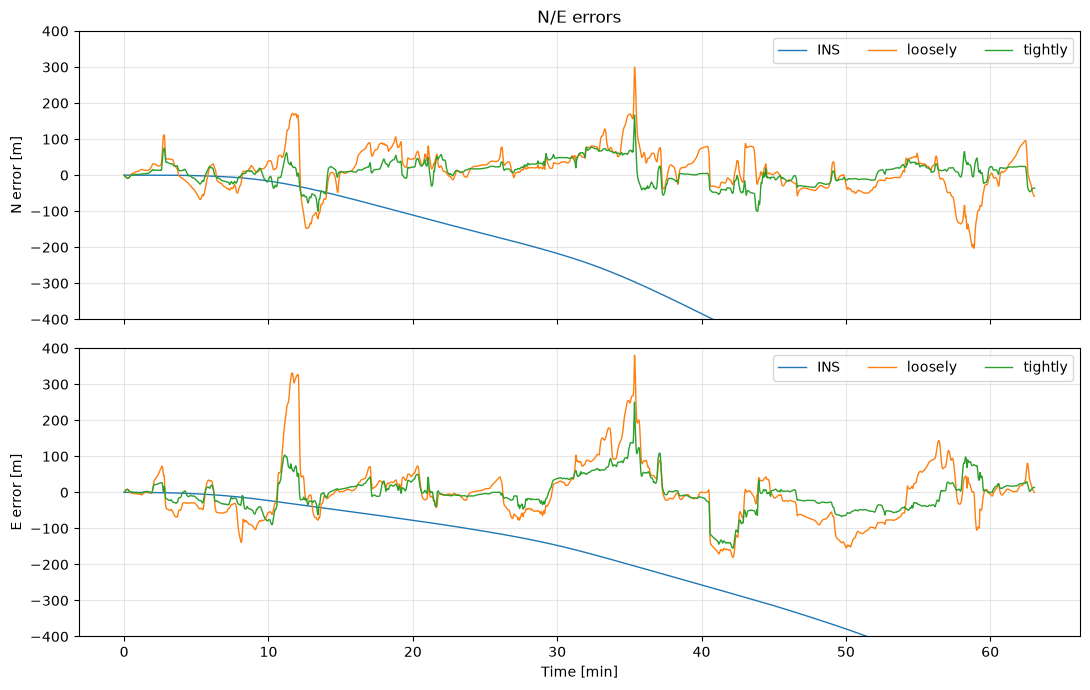

In [8]:
viz.plot_ne_errors(tt, lat, lon,
    {'INS': (ins_result,'tab:blue'), 'loosely': (loose,'tab:orange'), 'tightly': (tight,'tab:green')});

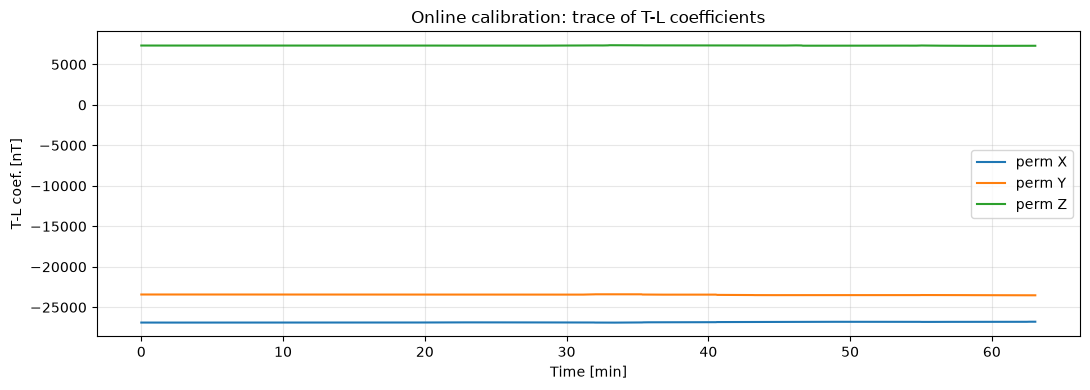

In [9]:
viz.plot_tl_online(tt, tight.extras['tl']);

On this data loosely ~100 m → tightly ~56 m (~44% better), close to Table I of the paper (F-16: 111 m → 59 m). To try another flight, change the flight/window (see `data.NAV_WINDOWS`).